In [31]:
# importing standard libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# REGRESSION PROBLEMS

In [4]:
# importing data

from sklearn.datasets import load_diabetes, fetch_california_housing

diabetes = load_diabetes()
california = fetch_california_housing()

X_diabetes, y_diabetes = diabetes.data, diabetes.target
X_california, y_california = california.data, california.target

print(f'Diabeties Dataframe:{ X_diabetes.shape, y_diabetes.shape}')
print(f'California Dataframe:{ X_california.shape, y_california.shape}')

Diabeties Dataframe:((442, 10), (442,))
California Dataframe:((20640, 8), (20640,))


# FETAURE UNDERSTANDING

In [7]:
df_diabetes = pd.DataFrame(X_diabetes, columns=diabetes.feature_names)
df_diabetes['target'] = y_diabetes
df_diabetes.describe().T


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [8]:
df_california = pd.DataFrame(X_california, columns=california.feature_names)
df_california['target'] = y_california
df_california.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


# OBSERVATIONS
- diabeties data is scaled and low  volume, california data is more robust with notscaled values

# LINEAR REGRESSOR

In [33]:
def gradient(x, y, w, b, lr=0.001):
    m = x.shape[0]

    y_pred = x @ w + b
    error = y_pred - y           

    dw = (1 / m) * (x.T @ error) 
    db = (1 / m) * np.sum(error)

    w = w - lr * dw
    b = b - lr * db

    return w, b

In [34]:
def tickr(x, y, w, b):
    m = x.shape[0]
    error = (x @ w + b) - y
    return (1 / (2 * m)) * np.sum(error ** 2)

In [39]:
def lr(x, y, data, epochs=50000):

    m = x.shape[0]
    w = np.zeros(x.shape[1])
    b = 0.0

    for i in range(epochs):
        w, b = gradient(x, y, w, b)
        cost = tickr(x, y, w, b)
        if i % 100 == 0:
            print(f'iteration {i}: cost = {cost:.4f}')
            feature_names = data.feature_names
            terms = " + ".join(f"{wi:.3f}*{name}" for wi, name in zip(w, feature_names))
            print(f'\nequation: y = {terms} + {b:.3f}')
            
    y_pred = x @ w + b

    plt.scatter(y, y_pred, alpha=0.4)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Actual vs Predicted')
    plt.show()

    return w, b


#  TRAINING AND TESTING

iteration 0: cost = 14823.2340

equation: y = 0.015*age + 0.001*sex + 0.047*bmi + 0.035*bp + 0.016*s1 + 0.012*s2 + -0.030*s3 + 0.033*s4 + 0.043*s5 + 0.030*s6 + 0.154
iteration 100: cost = 12049.2282

equation: y = 1.240*age + -0.134*sex + 4.181*bmi + 3.041*bp + 1.131*s1 + 0.798*s2 + -2.564*s3 + 2.718*s4 + 3.719*s5 + 2.541*s6 + 14.776
iteration 200: cost = 9966.2781

equation: y = 1.999*age + -0.541*sex + 7.394*bmi + 5.321*bp + 1.598*s1 + 0.972*s2 + -4.384*s3 + 4.449*s4 + 6.418*s5 + 4.228*s6 + 28.006
iteration 300: cost = 8346.9223

equation: y = 2.450*age + -1.104*sex + 9.944*bmi + 7.082*bp + 1.665*s1 + 0.778*s2 + -5.709*s3 + 5.548*s4 + 8.439*s5 + 5.351*s6 + 39.977
iteration 400: cost = 7060.7223

equation: y = 2.699*age + -1.749*sex + 12.009*bmi + 8.469*bp + 1.493*s1 + 0.373*s2 + -6.687*s3 + 6.231*s4 + 9.986*s5 + 6.086*s6 + 50.808
iteration 500: cost = 6026.1359

equation: y = 2.818*age + -2.426*sex + 13.713*bmi + 9.582*bp + 1.186*s1 + -0.139*s2 + -7.421*s3 + 6.642*s4 + 11.199*s5 + 6.

iteration 1100: cost = 2820.2242

equation: y = 2.576*age + -6.053*sex + 19.834*bmi + 13.275*bp + -1.068*s1 + -3.188*s2 + -9.435*s3 + 7.018*s4 + 15.125*s5 + 6.918*s6 + 102.641
iteration 1200: cost = 2571.8183

equation: y = 2.501*age + -6.528*sex + 20.463*bmi + 13.623*bp + -1.374*s1 + -3.569*s2 + -9.586*s3 + 6.984*s4 + 15.508*s5 + 6.816*s6 + 107.506
iteration 1300: cost = 2368.5660

equation: y = 2.429*age + -6.965*sex + 21.024*bmi + 13.928*bp + -1.651*s1 + -3.910*s2 + -9.712*s3 + 6.949*s4 + 15.850*s5 + 6.700*s6 + 111.908
iteration 1400: cost = 2202.2295

equation: y = 2.361*age + -7.366*sex + 21.526*bmi + 14.196*bp + -1.903*s1 + -4.214*s2 + -9.818*s3 + 6.916*s4 + 16.158*s5 + 6.573*s6 + 115.890
iteration 1500: cost = 2066.0831

equation: y = 2.299*age + -7.733*sex + 21.976*bmi + 14.433*bp + -2.130*s1 + -4.483*s2 + -9.908*s3 + 6.885*s4 + 16.437*s5 + 6.439*s6 + 119.493
iteration 1600: cost = 1954.6317

equation: y = 2.241*age + -8.069*sex + 22.381*bmi + 14.643*bp + -2.335*s1 + -4.721*s2 

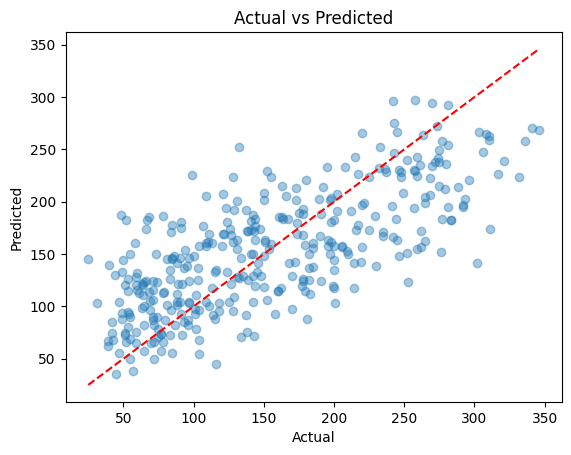

In [40]:
# DIABIETIES DATASET

X_train, X_test, y_train, y_test = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

w, b = lr(X_train, y_train, data = diabetes)


MSE: 2886.9824
R²: 0.4551


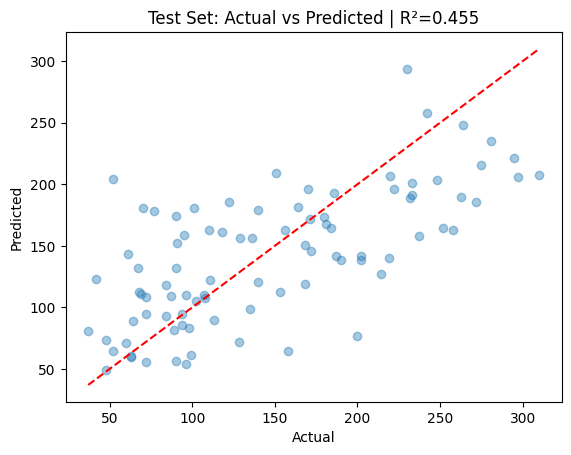

In [37]:
y_pred_test = X_test @ w + b

mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f'MSE: {mse:.4f}')
print(f'R²: {r2:.4f}')

plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Test Set: Actual vs Predicted | R²={r2:.3f}')
plt.show()


iteration 0: cost = 2.8099

equation: y = 0.001*MedInc + 0.000*HouseAge + 0.000*AveRooms + -0.000*AveBedrms + -0.000*Population + -0.000*AveOccup + -0.000*Latitude + -0.000*Longitude + 0.002
iteration 100: cost = 2.3566

equation: y = 0.076*MedInc + 0.012*HouseAge + 0.017*AveRooms + -0.006*AveBedrms + -0.003*Population + -0.003*AveOccup + -0.016*Latitude + -0.006*Longitude + 0.199


iteration 200: cost = 1.9863

equation: y = 0.144*MedInc + 0.024*HouseAge + 0.030*AveRooms + -0.012*AveBedrms + -0.005*Population + -0.005*AveOccup + -0.030*Latitude + -0.012*Longitude + 0.377
iteration 300: cost = 1.6836

equation: y = 0.205*MedInc + 0.035*HouseAge + 0.041*AveRooms + -0.018*AveBedrms + -0.007*Population + -0.007*AveOccup + -0.044*Latitude + -0.018*Longitude + 0.539
iteration 400: cost = 1.4360

equation: y = 0.260*MedInc + 0.046*HouseAge + 0.050*AveRooms + -0.023*AveBedrms + -0.008*Population + -0.009*AveOccup + -0.056*Latitude + -0.025*Longitude + 0.685
iteration 500: cost = 1.2334

equation: y = 0.310*MedInc + 0.056*HouseAge + 0.057*AveRooms + -0.028*AveBedrms + -0.009*Population + -0.012*AveOccup + -0.067*Latitude + -0.032*Longitude + 0.817
iteration 600: cost = 1.0675

equation: y = 0.354*MedInc + 0.066*HouseAge + 0.062*AveRooms + -0.032*AveBedrms + -0.009*Population + -0.014*AveOccup + -0.078*Latitude + -0.039*Longitude + 0.936
iteration 700: cost = 0.9317

equat

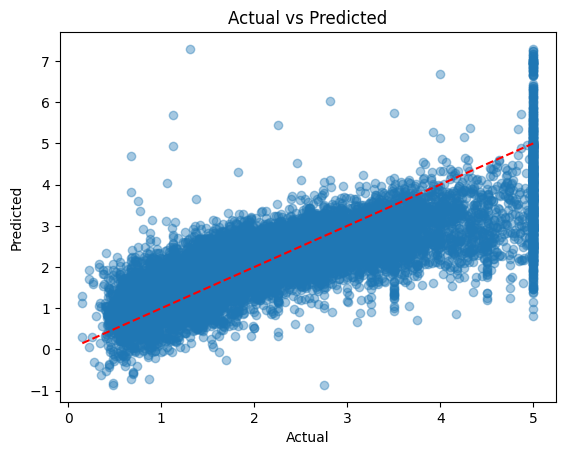

In [41]:
# CALIFORNIA DATASET

X_train, X_test, y_train, y_test = train_test_split(X_california, y_california, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

w, b = lr(X_train, y_train, data = california)

MSE: 0.5562
R²: 0.5756


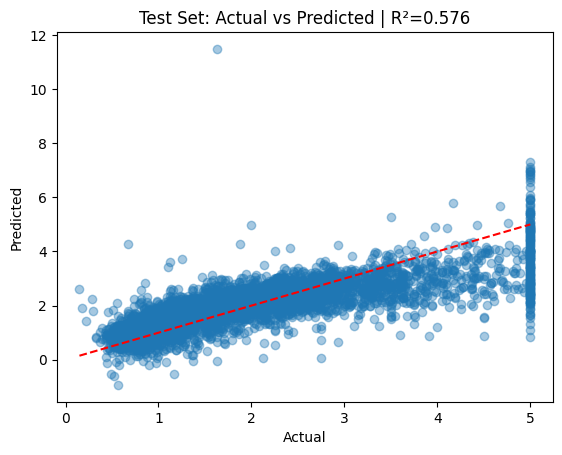

In [42]:
y_pred_test = X_test @ w + b

mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f'MSE: {mse:.4f}')
print(f'R²: {r2:.4f}')

plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Test Set: Actual vs Predicted | R²={r2:.3f}')
plt.show()


# REGULARIZED LINEAR REGRESSOR
 - RIDGE
 - LASSO

In [ ]:
def gradient(x, y, w,b, model):
    
    lambda_ = 0.1
    lr =0.1
    m = x.shape[0]

    if model=='ridge':
        penalty = w
    else:
        penalty = np.sign(w) 

    y_pred = x @ w + b 
    error = y_pred - y           

    dw = (1 / m) * ((x.T @ error) + lambda_ * penalty)
    db = (1 / m) * np.sum(error)

    w = w - lr * dw
    b = b - lr * db
    
    return w,b

In [ ]:
def tickr(x,y,w,b,model):

    m = x.shape[0]
    if model=='ridge':
        penalty = w**2
    else:        
        penalty = np.abs(w)

    error = (x @ w + b) - y 
    return (1 / (2 * m)) * (np.sum(error ** 2) + np.sum(penalty))

In [71]:
def regularized_lr(x,y, data, model='ridge', epochs=10000):
    m = x.shape[0]
    w = np.zeros(x.shape[1])
    b = 0.0

    for i in range(epochs):
        w, b = gradient(x, y, w, b, model)
        cost = tickr(x, y, w, b,model)
        if i % 100 == 0:
            print(f'iteration {i}: cost = {cost:.4f}')
            feature_names = data.feature_names
            terms = " + ".join(f"{wi:.3f}*{name}" for wi, name in zip(w, feature_names))
            print(f'\nequation: y = {terms} + {b:.3f}')
            
    y_pred = x @ w + b

    plt.scatter(y, y_pred, alpha=0.4)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Actual vs Predicted')
    plt.show()

    return w, b

# TRAINING AND TESTING

iteration 0: cost = 11882.6795

equation: y = 1.532*age + 0.055*sex + 4.714*bmi + 3.467*bp + 1.555*s1 + 1.208*s2 + -2.993*s3 + 3.314*s4 + 4.304*s5 + 3.043*s6 + 15.374
iteration 100: cost = 1449.8212

equation: y = 1.946*age + -11.419*sex + 26.313*bmi + 16.574*bp + -6.558*s1 + -4.787*s2 + -9.273*s3 + 7.532*s4 + 20.711*s5 + 2.663*s6 + 153.733
iteration 200: cost = 1447.7202

equation: y = 1.937*age + -11.428*sex + 26.261*bmi + 16.604*bp + -9.893*s1 + -2.290*s2 + -7.675*s3 + 8.204*s4 + 21.952*s5 + 2.606*s6 + 153.737
iteration 300: cost = 1446.0432

equation: y = 1.923*age + -11.438*sex + 26.205*bmi + 16.627*bp + -12.923*s1 + 0.031*s2 + -6.281*s3 + 8.719*s4 + 23.086*s5 + 2.584*s6 + 153.737
iteration 400: cost = 1444.7085

equation: y = 1.909*age + -11.446*sex + 26.154*bmi + 16.646*bp + -15.676*s1 + 2.161*s2 + -5.039*s3 + 9.143*s4 + 24.129*s5 + 2.564*s6 + 153.737
iteration 500: cost = 1443.6515

equation: y = 1.896*age + -11.452*sex + 26.106*bmi + 16.662*bp + -18.177*s1 + 4.106*s2 + -3.923*

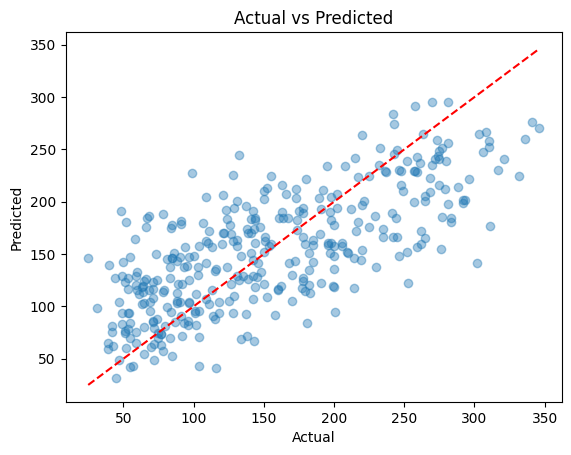

In [72]:
# DIABIETIES DATASET

X_train, X_test, y_train, y_test = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

w, b = regularized_lr(X_train, y_train, data = diabetes, model='ridge')

MSE: 2899.0522
R²: 0.4528


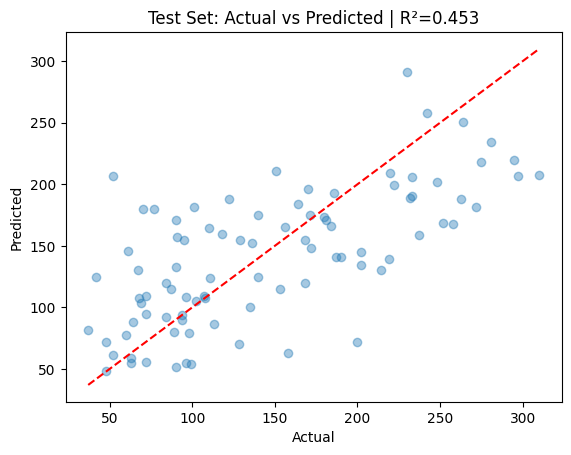

In [73]:
# predictions

y_pred_test = X_test @ w + b
error = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f'MSE: {error:.4f}')
print(f'R²: {r2:.4f}')  

# plottings

plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Test Set: Actual vs Predicted | R²={r2:.3f}')
plt.show()  

iteration 0: cost = 11882.5916

equation: y = 1.532*age + 0.055*sex + 4.714*bmi + 3.467*bp + 1.555*s1 + 1.208*s2 + -2.993*s3 + 3.314*s4 + 4.304*s5 + 3.043*s6 + 15.374
iteration 100: cost = 1447.4973

equation: y = 1.946*age + -11.422*sex + 26.319*bmi + 16.577*bp + -6.564*s1 + -4.786*s2 + -9.273*s3 + 7.532*s4 + 20.717*s5 + 2.659*s6 + 153.733
iteration 200: cost = 1445.2880

equation: y = 1.937*age + -11.432*sex + 26.267*bmi + 16.607*bp + -9.913*s1 + -2.278*s2 + -7.668*s3 + 8.207*s4 + 21.963*s5 + 2.602*s6 + 153.737
iteration 300: cost = 1443.4567

equation: y = 1.923*age + -11.442*sex + 26.211*bmi + 16.630*bp + -12.965*s1 + 0.059*s2 + -6.264*s3 + 8.725*s4 + 23.105*s5 + 2.580*s6 + 153.737
iteration 400: cost = 1441.9424

equation: y = 1.909*age + -11.449*sex + 26.158*bmi + 16.649*bp + -15.742*s1 + 2.207*s2 + -5.011*s3 + 9.154*s4 + 24.158*s5 + 2.559*s6 + 153.737
iteration 500: cost = 1440.6843

equation: y = 1.896*age + -11.456*sex + 26.110*bmi + 16.666*bp + -18.274*s1 + 4.176*s2 + -3.881*

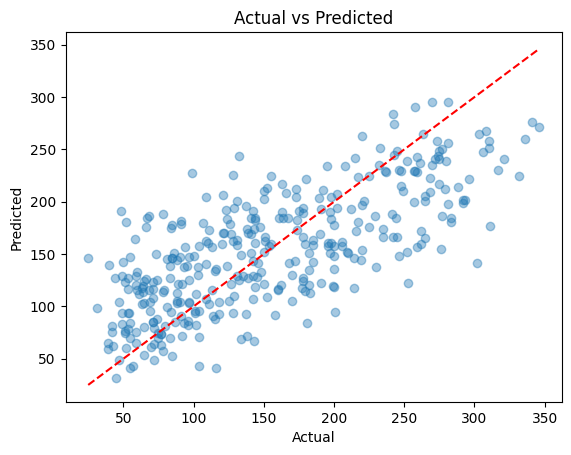

In [74]:
# DIABIETIES DATASET

X_train, X_test, y_train, y_test = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

w, b = regularized_lr(X_train, y_train, data = diabetes, model='lasso')

MSE: 2900.1381
R²: 0.4526


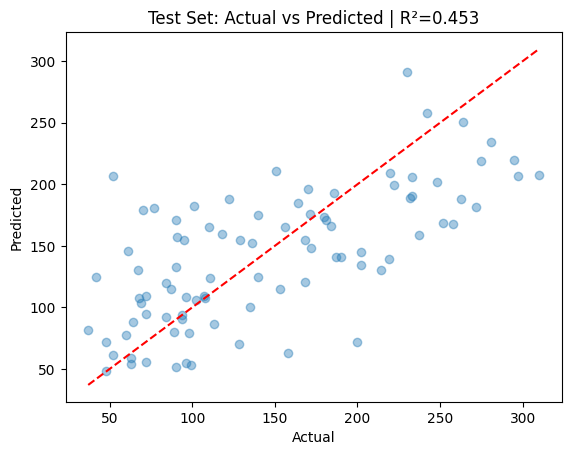

In [75]:
# predictions 

y_pred_test = X_test @ w + b
error = mean_squared_error(y_test, y_pred_test)             
r2 = r2_score(y_test, y_pred_test)
print(f'MSE: {error:.4f}')
print(f'R²: {r2:.4f}')          

# plottings 
plt.scatter(y_test, y_pred_test, alpha=0.4)         
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Test Set: Actual vs Predicted | R²={r2:.3f}')
plt.show()

iteration 0: cost = 2.3389

equation: y = 0.080*MedInc + 0.012*HouseAge + 0.018*AveRooms + -0.006*AveBedrms + -0.003*Population + -0.003*AveOccup + -0.017*Latitude + -0.005*Longitude + 0.207
iteration 100: cost = 0.2736

equation: y = 0.830*MedInc + 0.178*HouseAge + -0.141*AveRooms + 0.159*AveBedrms + 0.017*Population + -0.045*AveOccup + -0.491*Latitude + -0.455*Longitude + 2.072
iteration 200: cost = 0.2623

equation: y = 0.858*MedInc + 0.150*HouseAge + -0.254*AveRooms + 0.282*AveBedrms + 0.007*Population + -0.043*AveOccup + -0.685*Latitude + -0.656*Longitude + 2.072
iteration 300: cost = 0.2598

equation: y = 0.865*MedInc + 0.136*HouseAge + -0.293*AveRooms + 0.328*AveBedrms + 0.002*Population + -0.042*AveOccup + -0.783*Latitude + -0.756*Longitude + 2.072
iteration 400: cost = 0.2593

equation: y = 0.865*MedInc + 0.130*HouseAge + -0.304*AveRooms + 0.343*AveBedrms + 0.000*Population + -0.042*AveOccup + -0.834*Latitude + -0.808*Longitude + 2.072
iteration 500: cost = 0.2591

equation: y

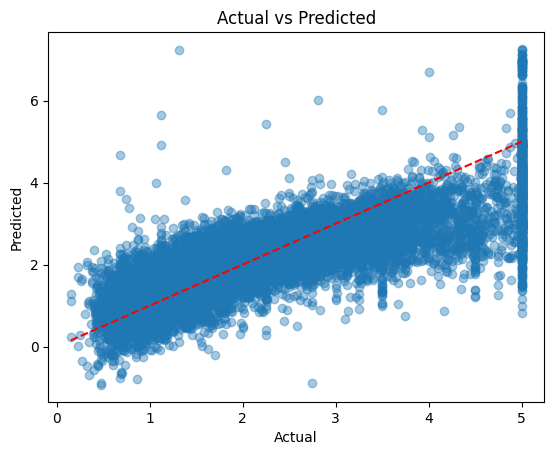

In [76]:
# california dataset

X_train, X_test, y_train, y_test = train_test_split(X_california, y_california, test_size=0.2, random_state=42) 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   
w, b = regularized_lr(X_train, y_train, data = california, model='ridge')   


MSE: 0.5559
R²: 0.5758


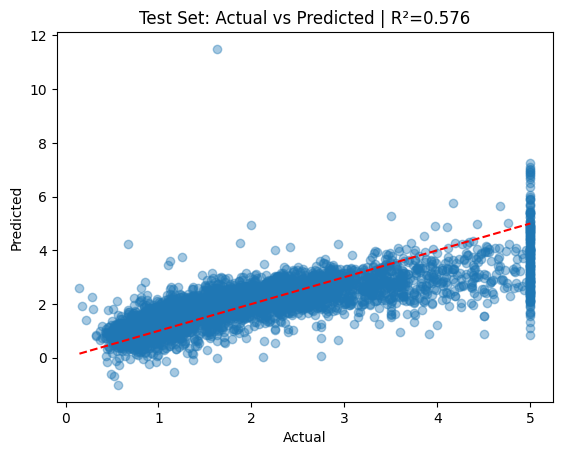

In [77]:
# predictions

y_pred_test = X_test @ w + b
error = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f'MSE: {error:.4f}')
print(f'R²: {r2:.4f}')

# plottings
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Test Set: Actual vs Predicted | R²={r2:.3f}')
plt.show()  

iteration 0: cost = 2.3389

equation: y = 0.080*MedInc + 0.012*HouseAge + 0.018*AveRooms + -0.006*AveBedrms + -0.003*Population + -0.003*AveOccup + -0.017*Latitude + -0.005*Longitude + 0.207
iteration 100: cost = 0.2736

equation: y = 0.830*MedInc + 0.178*HouseAge + -0.140*AveRooms + 0.159*AveBedrms + 0.017*Population + -0.045*AveOccup + -0.491*Latitude + -0.455*Longitude + 2.072
iteration 200: cost = 0.2623

equation: y = 0.858*MedInc + 0.150*HouseAge + -0.254*AveRooms + 0.282*AveBedrms + 0.007*Population + -0.043*AveOccup + -0.685*Latitude + -0.656*Longitude + 2.072
iteration 300: cost = 0.2599

equation: y = 0.865*MedInc + 0.136*HouseAge + -0.293*AveRooms + 0.328*AveBedrms + 0.002*Population + -0.042*AveOccup + -0.783*Latitude + -0.756*Longitude + 2.072
iteration 400: cost = 0.2593

equation: y = 0.865*MedInc + 0.130*HouseAge + -0.304*AveRooms + 0.342*AveBedrms + 0.000*Population + -0.042*AveOccup + -0.834*Latitude + -0.808*Longitude + 2.072
iteration 500: cost = 0.2591

equation: y

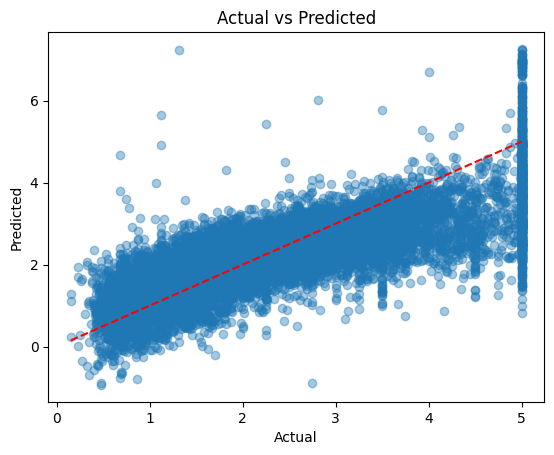

In [78]:
# california dataset

X_train, X_test, y_train, y_test = train_test_split(X_california, y_california, test_size=0.2, random_state=42) 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   
w, b = regularized_lr(X_train, y_train, data = california, model='lasso')   


MSE: 0.5559
R²: 0.5758


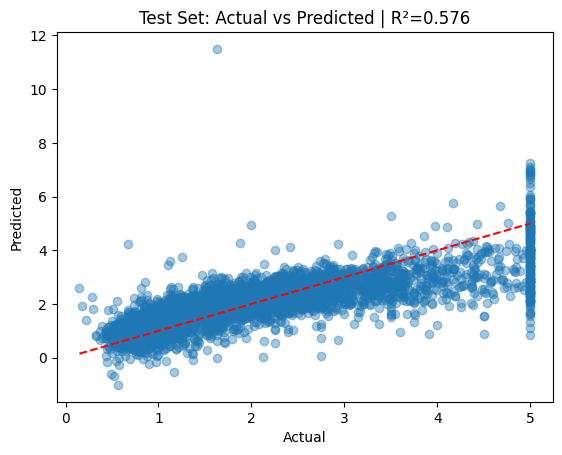

In [79]:
# predictions 

y_pred_test = X_test @ w + b
error = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f'MSE: {error:.4f}')
print(f'R²: {r2:.4f}')      

# plottings
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Test Set: Actual vs Predicted | R²={r2:.3f}')
plt.show()

# CLASSIFICATION PROBLEMS

# LOGISTIC REGRESSOR

In [ ]:
def logr(x, y):
    m = x.shape[0]
    w = np.zeros(x.shape[1])
    b = 0.0
    lr = 0.01

    for i in range(10000):
        y_pred = 1 / (1 + np.exp(-(x @ w + b)))
        error = y_pred - y

        dw = (1 / m) * (x.T @ error)
        db = (1 / m) * np.sum(error)

        w = w - lr * dw
        b = b - lr * db

        if i % 100 == 0:
            cost = -np.mean(y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15))
            print(f'iteration {i}: cost = {cost:.4f}')

    # decision boundary: vary features 0 and 1, hold the rest at 0 (standardized mean)
    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.zeros((xx.ravel().shape[0], x.shape[1]))
    grid[:, 0] = xx.ravel()
    grid[:, 1] = yy.ravel()
    Z = 1 / (1 + np.exp(-(grid @ w + b)))
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])
    plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Logistic Regression Decision Boundary')
    plt.show()

    return w, b

In [ ]:
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.metrics import accuracy_score, confusion_matrix

breast_cancer = load_breast_cancer()
iris = load_iris()

print(f'Breast Cancer: {breast_cancer.data.shape}, classes: {breast_cancer.target_names}')
print(f'Iris: {iris.data.shape}, classes: {iris.target_names}')

# TRAINING AND TESTING

In [ ]:
# BREAST CANCER DATASET
X_train, X_test, y_train, y_test = train_test_split(breast_cancer.data, breast_cancer.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

w, b = logr(X_train, y_train)

In [ ]:
# predictions
y_pred = (1 / (1 + np.exp(-(X_test @ w + b)))) >= 0.5

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}')

In [ ]:
# IRIS DATASET (binary: setosa vs versicolor, classes 0 and 1)
mask = iris.target < 2
X_train, X_test, y_train, y_test = train_test_split(iris.data[mask], iris.target[mask], test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

w, b = logr(X_train, y_train)

In [ ]:
# predictions
y_pred = (1 / (1 + np.exp(-(X_test @ w + b)))) >= 0.5

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}')

# FEATURE ENGINEERING
- does adding / engineering features improve performance?

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# helper: train linear regression from scratch and return test R²
def train_linear(X, y, epochs=10000, lr=0.01):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    m = X_tr.shape[0]
    w, b = np.zeros(X_tr.shape[1]), 0.0
    for _ in range(epochs):
        err = X_tr @ w + b - y_tr
        w -= lr * (1 / m) * (X_tr.T @ err)
        b -= lr * (1 / m) * err.sum()
    return r2_score(y_te, X_te @ w + b)

df_ca = pd.DataFrame(california.data, columns=california.feature_names)
y_ca  = california.target

# 1. baseline
r2_base = train_linear(california.data, y_ca)

# 2. + 3 engineered features
df_ca['bedroom_ratio'] = df_ca['AveBedrms'] / df_ca['AveRooms']
df_ca['households']    = df_ca['Population'] / df_ca['AveOccup']
df_ca['income_rooms']  = df_ca['MedInc'] * df_ca['AveRooms']
r2_eng = train_linear(df_ca.values, y_ca)

# 3. + polynomial features (degree 2) — needs more epochs to converge (77 features vs 11)
X_poly = PolynomialFeatures(degree=2, include_bias=False).fit_transform(df_ca.values)
r2_poly = train_linear(X_poly, y_ca, epochs=100000)

print(f'Baseline (8 features)            R² = {r2_base:.4f}')
print(f'+ 3 engineered features          R² = {r2_eng:.4f}  (Δ {r2_eng - r2_base:+.4f})')
print(f'+ polynomial features (deg 2)    R² = {r2_poly:.4f}  (Δ {r2_poly - r2_base:+.4f})')

# LEARNING RATE OPTIMISATION
- how do we find the best learning rate, and does it matter?

In [ ]:
# grid search over learning rates on the engineered california feature set
lrs = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
r2_scores = []

for lr in lrs:
    r2 = train_linear(df_ca.values, y_ca, lr=lr)
    r2_scores.append(r2)
    print(f'lr = {lr:.4f}   R² = {r2:.4f}')

best_idx = int(np.argmax(r2_scores))
print(f'\nbest lr: {lrs[best_idx]}  →  R² = {r2_scores[best_idx]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(lrs, r2_scores, 'o-')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Test R²')
plt.title('Learning Rate vs Test R²')
plt.axvline(lrs[best_idx], color='r', linestyle='--', label=f'best lr = {lrs[best_idx]}')
plt.legend()
plt.grid(True)
plt.show()